# Red Neuronal ART1 (Carpenter-Grossberg) aplicada al diagnóstico médico

## Trabajo Final Integrador — demostración ejecutable paso a paso

Este notebook acompaña la defensa del Trabajo Final Integrador de la materia
**Redes Neuronales**. Su objetivo es mostrar, de forma ejecutable y verificable,
cómo una red **ART1** (Adaptive Resonance Theory 1) de Carpenter y Grossberg
agrupa perfiles sintomáticos de pacientes sin supervisión previa y cómo ese
agrupamiento se traduce en derivaciones a especialidades médicas.

**Qué es ART1 en una frase.** Es una red de clustering no supervisado para
patrones **binarios** que aprende categorías de forma incremental y resuelve el
dilema de *estabilidad-plasticidad*: puede aprender patrones nuevos sin borrar
lo que ya aprendió.

**Qué resuelve este TFI.** Dada una planilla de pacientes donde cada síntoma es
un bit (presente / ausente), la red forma *clusters* de pacientes parecidos,
calcula una **plantilla representativa** por cluster y sugiere una especialidad
médica de derivación, todo sin etiquetas de entrenamiento.

**Qué va a ver quien expone.** Este notebook está pensado para leerse en voz
alta durante la defensa, en este orden:

1. Qué es ART1 y qué resuelve el TFI.
2. El marco teórico, fórmula por fórmula, explicando *qué hace* cada una.
3. La carga real de los datos (100 pacientes, 5 síntomas) y su saneo.
4. La vectorización binaria de los síntomas.
5. **El algoritmo ART1 paso a paso, con un ejemplo rastreado con números concretos.**
6. El entrenamiento completo sobre los 100 registros.
7. Los resultados y las métricas del sistema.
8. Las visualizaciones (plantillas, distribución, evolución y barrido de ρ).
9. La validación externa contra especialidades esperadas.
10. La discusión, las limitaciones y los aspectos éticos.
11. Cómo reproducir todo desde la línea de comandos (CLI).

### Tabla de contenidos

| # | Sección | Idea clave |
|---|---------|------------|
| 2 | Marco teórico ART1 | F1/F2, vigilancia, resonancia/reset |
| 3 | Carga de datos | Detección CSV/XLSX, normalización, columnas fantasma |
| 4 | Preprocesamiento | Vectorización binaria de síntomas |
| 5 | ART1 paso a paso | Ejemplo rastreado con números a mano |
| 6 | Entrenamiento completo | 100 registros, ρ = 0.65 |
| 7 | Resultados y métricas | Clusters, plantillas, matching ratio, estabilidad |
| 8 | Visualizaciones | Heatmap, distribución, evolución, barrido de ρ |
| 9 | Validación externa | Pureza de clusters |
| 10 | Discusión y limitaciones | Estabilidad-plasticidad, sesgos, ética |
| 11 | Cómo reproducir el CLI | Comandos verificados contra `src/CarGross.py` |

> **Nota de alcance.** El sistema es una herramienta de apoyo académico.
> Todo diagnóstico debe ser validado por un profesional médico.

In [1]:
# Primera celda de código: configuración del entorno de gráficos e imports.
%matplotlib inline

import math
import os
import re
import subprocess
import sys
import random
import tempfile
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt

# Estilo sobrio y legible en proyección (con respaldo si no está disponible).
for _estilo in ("seaborn-v0_8-whitegrid", "ggplot"):
    if _estilo in plt.style.available:
        plt.style.use(_estilo)
        break

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "figure.dpi": 95,
    "savefig.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

# Paleta de colores del notebook (sobria, apta para impresión).
PALETA = {
    "azul": "#2c5f8a",
    "rojo": "#b7322d",
    "verde": "#3e7d5a",
    "ocre": "#c98a32",
    "gris": "#6b6b6b",
    "violeta": "#6a4c93",
}

print("Python:", sys.version.split()[0])
print("matplotlib:", mpl.__version__)
print("Estilo de gráficos:", "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "ggplot")
print("Paleta del notebook:", PALETA)

Python: 3.12.1
matplotlib: 3.10.5
Estilo de gráficos: seaborn-v0_8-whitegrid
Paleta del notebook: {'azul': '#2c5f8a', 'rojo': '#b7322d', 'verde': '#3e7d5a', 'ocre': '#c98a32', 'gris': '#6b6b6b', 'violeta': '#6a4c93'}


In [2]:
# Resolución robusta de la raíz del repo: funciona desde notebooks/ o desde la raíz.
def encontrar_raiz(inicio: Path) -> Path:
    actual = inicio.resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / "src" / "CarGross.py").exists():
            return candidato
    raise RuntimeError(f"No se encontró src/CarGross.py subiendo desde {inicio}")

RAIZ = encontrar_raiz(Path.cwd())
sys.path.insert(0, str(RAIZ / "src"))

# Se importa el MISMO módulo que usa el CLI, no una copia.
import CarGross as cg

RUTA_TRAIN = RAIZ / "data" / "dataset_entrenamiento_ART1.xlsx"
RUTA_VAL = RAIZ / "data" / "dataset_validacion_ART1.xlsx"

print("Raíz del repo      :", RAIZ)
print("Módulo importado   :", cg.__file__)
print("Dataset entrenamiento existe:", RUTA_TRAIN.exists(), "->", RUTA_TRAIN.name)
print("Dataset validación existe   :", RUTA_VAL.exists(), "->", RUTA_VAL.name)

Raíz del repo      : C:\Users\camil\Proyectos\ia2026
Módulo importado   : C:\Users\camil\Proyectos\ia2026\src\CarGross.py
Dataset entrenamiento existe: True -> dataset_entrenamiento_ART1.xlsx
Dataset validación existe   : True -> dataset_validacion_ART1.xlsx


## 2. Marco teórico de ART1

ART1 fue propuesta por **Gail Carpenter y Stephen Grossberg** para agrupar
patrones **binarios**. La red tiene dos capas conectadas por dos juegos de
pesos, y un mecanismo de control llamado **test de vigilancia** que decide si un
patrón se acepta en una categoría o se busca otra.

### 2.1 Las dos capas: F1 y F2

* **F1 (capa de comparación):** recibe el vector de entrada $x = (x_1, \dots, x_N)$
  con $x_i \in \{0, 1\}$. En nuestro caso $N = 5$ síntomas.
* **F2 (capa de reconocimiento):** contiene $M$ nodos de categoría (nosotros
  $M = 50$). Gana la categoría más activa por *inhibición lateral* (winner take all).
* **Pesos ascendentes o bottom-up $b_{ij}$:** conectan la entrada $i$ con la
  categoría $j$. Filtran la entrada hacia F2 y definen qué categoría "reconoce"
  el patrón.
* **Pesos descendentes o top-down $t_{ji}$:** conectan la categoría $j$ con la
  entrada $i$. Son la **plantilla prototipo** que la categoría aprendió.

### 2.2 Inicialización de los pesos

$$b_{ij}(0) = \frac{1}{1 + N} \qquad \qquad t_{ji}(0) = 1$$

**Qué hace:** al arrancar, todas las categorías son idénticas e "interesadas en
todo": la plantilla $t$ llena de unos acepta cualquier patrón, y los pesos $b$
iguales hacen que la primera categoría empatada gane (en la práctica, la de
índice menor). Con $N = 5$, cada $b_{ij}(0) = 1/6 \approx 0{,}1667$.

### 2.3 Activación de la capa F2 (competencia)

$$\mu_j = \sum_{i=1}^{N} b_{ij}\, x_i$$

**Qué hace:** mide cuánto "reconoce" la categoría $j$ al patrón $x$. Como $x$ es
binario, la suma solo acumula los pesos $b_{ij}$ de los síntomas presentes.
La categoría ganadora es

$$j^* = \arg\max_{j} \ \mu_j$$

En caso de empate se elige la categoría de índice menor: esa convención parece
menor, pero **fija el orden de creación de los clusters** y por eso importa
para que dos implementaciones den el mismo resultado.

### 2.4 Coincidencia descendente (operador AND) y norma

La plantilla de la categoría ganadora se intersecta con el patrón mediante un
**AND lógico** (producto con valores 0/1):

$$T_i = t_{j^*i} \wedge x_i \;=\; t_{j^*i} \cdot x_i$$

**Qué hace:** $T$ conserva solo los síntomas que están **a la vez** en la
plantilla y en el paciente. Si la plantilla tenía un síntoma que el paciente no
tiene, ese bit se apaga en $T$. Es decir: $T$ es "lo que la categoría y el
paciente comparten".

La norma de un vector binario es simplemente la cantidad de bits activos:

$$\|x\| = \sum_{i=1}^{N} |x_i| = \sum_{i=1}^{N} x_i$$

### 2.5 Matching ratio y umbral de vigilancia

El **matching ratio** es la proporción del patrón que la plantilla logra
explicar:

$$\frac{\|T\|}{\|x\|} = \frac{\sum_{i=1}^{N} t_{j^*i}\, x_i}{\sum_{i=1}^{N} x_i}$$

**Qué hace:** responde "¿qué fracción de los síntomas de este paciente están
contenidos en la plantilla del cluster?". Si el paciente tiene 2 síntomas y la
plantilla contiene solo 1 de ellos, el ratio es $1/2 = 0{,}5$.

El **umbral de vigilancia** $\rho \in [0, 1]$ es el nivel de exigencia:

$$\frac{\|T\|}{\|x\|} \ge \rho \;\;\Rightarrow\; \text{resonancia (acepto } j^*)$$
$$\frac{\|T\|}{\|x\|} < \rho \;\;\Rightarrow\; \text{reset (descarto } j^* \text{ y pruebo otra categoría)}$$

**Qué hace:** con $\rho$ alto la red exige que el paciente se parezca mucho al
cluster y crea **más categorías, más puras pero más chicas**. Con $\rho$ bajo
tolera diferencias y forma **pocos clusters, más heterogéneos**. Es la
perilla que regula la granularidad del diagnóstico.

### 2.6 Ciclo resonancia / reset

Para cada patrón de entrada la red repite este ciclo:

1. Se calculan los puntajes $\mu_j$ sobre las categorías **todavía activas**.
2. Gana $j^*$.
3. Se calcula $T$ (AND) y el matching ratio.
4. Si $\|T\| / \|x\| \ge \rho$: hay **resonancia**, se adaptan los pesos y terminó.
5. Si no: la categoría $j^*$ se **desactiva para este patrón** y vuelve al paso 1.
6. Si todas las categorías quedaron desactivadas, se **crea una categoría nueva**
   (que estaba "virgen" y acepta el patrón con ratio $1$).

**Qué hace:** garantiza que ningún patrón quede dentro de un cluster con el que
no se parece lo suficiente: siempre termina en el mejor cluster aceptable o en
uno nuevo.

### 2.7 Adaptación de los pesos (regla del operador AND)

Cuando hay resonancia, la plantilla se actualiza a la intersección y los pesos
ascendentes se renormalizan:

$$t_{j^*i}^{\text{nuevo}} = T_i = t_{j^*i} \wedge x_i$$

$$b_{ij}^{\text{nuevo}} = \frac{t_{j^*i}^{\text{nuevo}}}{0{,}5 + \sum_{k=1}^{N} t_{j^*k}^{\text{nuevo}}}$$

**Qué hace:** la plantilla **solo puede perder bits, nunca ganar**: es una
intersección acumulada de todos los pacientes del cluster. La constante $0{,}5$
en el denominador es la normalización típica de la formulación de Lippmann
(1987) y evita que el peso total llegue a 1; así, una categoría comprometida no
puede empatar indefinidamente con las libres.

### 2.8 El dilema estabilidad-plasticidad

Una red que siempre acepta aprender (plástica) termina destruyendo lo aprendido
al llegar un patrón ruidoso; una que nunca cambia (estable) no aprende nada
nuevo. ART1 lo resuelve con el test de vigilancia: **solo aprende cuando la
coincidencia supera $\rho$**, y lo que aprende es una intersección, que es
conservadora. Por eso puede memorizar categorías nuevas sin reescribir las viejas.

## 3. Carga de datos

El sistema usa la función `load_dataset` de `src/CarGross.py`. Detecta el
formato por la extensión del archivo (`.csv` o `.xlsx`, tolerante a
mayúsculas), normaliza cada celda a texto y devuelve cuatro cosas:

1. la **matriz binaria** de patrones,
2. los **nombres de features** (síntomas),
3. las **etiquetas** de especialidad, si el archivo las tiene (solo validación),
4. los **identificadores** de paciente.

Los archivos reales del TFI son dos planillas de 100 registros:
`dataset_entrenamiento_ART1.xlsx` (sin etiquetas) y
`dataset_validacion_ART1.xlsx` (con la columna *Especialidad esperada*).

In [3]:
# Carga de los dos datasets reales del TFI.
patrones, nombres_features, etiquetas_train, ids_train = cg.load_dataset(str(RUTA_TRAIN))
patrones_val, nombres_val, etiquetas_val, ids_val = cg.load_dataset(str(RUTA_VAL))

print("== DATASET DE ENTRENAMIENTO ==")
print("Registros :", len(patrones))
print("Síntomas  :", nombres_features)
print("Etiquetas :", etiquetas_train, "(este archivo no trae etiquetas)")
print("Primeras filas (id -> vector binario):")
for pid, vec in list(zip(ids_train, patrones))[:6]:
    print(f"   {pid} -> {vec}")

print()
print("== DATASET DE VALIDACIÓN ==")
print("Registros :", len(patrones_val))
print("Síntomas  :", nombres_val)
print("Etiquetas distintas:", sorted(set(etiquetas_val)))
print("Primeras filas (id -> vector -> etiqueta esperada):")
for pid, vec, lab in list(zip(ids_val, patrones_val, etiquetas_val))[:6]:
    print(f"   {pid} -> {vec} -> {lab}")

== DATASET DE ENTRENAMIENTO ==
Registros : 100
Síntomas  : ['Tos', 'Moco', 'Fiebre', 'Dolor abdominal', 'Presión alta']
Etiquetas : None (este archivo no trae etiquetas)
Primeras filas (id -> vector binario):
   P015 -> [1, 0, 0, 0, 0]
   P075 -> [0, 0, 1, 0, 0]
   P021 -> [1, 0, 0, 0, 1]
   P082 -> [1, 1, 0, 0, 0]
   P068 -> [0, 1, 1, 0, 0]
   P064 -> [0, 0, 1, 0, 0]

== DATASET DE VALIDACIÓN ==
Registros : 100
Síntomas  : ['Tos', 'Moco', 'Fiebre', 'Dolor abdominal', 'Presión alta']
Etiquetas distintas: ['Cardiología', 'Gastroenterología', 'Infectología', 'Medicina general', 'Neumología']
Primeras filas (id -> vector -> etiqueta esperada):
   P187 -> [1, 0, 0, 0, 0] -> Medicina general
   P104 -> [1, 1, 0, 0, 0] -> Neumología
   P188 -> [1, 0, 0, 0, 1] -> Medicina general
   P167 -> [1, 0, 1, 0, 0] -> Infectología
   P178 -> [0, 1, 1, 0, 0] -> Infectología
   P165 -> [0, 0, 1, 0, 0] -> Infectología


### 3.1 Detección CSV / XLSX y equivalencia de formatos

La detección es trivial pero importante para la robustez: `load_dataset` mira la
extensión y elige el lector (`_read_csv_rows` para CSV, `_read_xlsx_rows` para
Excel). El lector de Excel usa `openpyxl` si está instalado y, si no, un lector
interno sin dependencias basado en `zipfile` + `xml.etree` (un `.xlsx` es un ZIP
con XML adentro).

La garantía que da el módulo es: **el mismo dataset en CSV o en XLSX produce
exactamente los mismos vectores**. Lo verificamos acá con los archivos `_demo`
que replican las planillas en formato CSV.

In [4]:
# Equivalencia CSV <-> XLSX: mismo contenido, mismo resultado.
RUTA_TRAIN_CSV = RAIZ / "data" / "_demo_entrenamiento.csv"
RUTA_VAL_CSV = RAIZ / "data" / "_demo_validacion.csv"

patrones_csv, feats_csv, etiq_csv, ids_csv = cg.load_dataset(str(RUTA_TRAIN_CSV))
print("CSV vs XLSX (entrenamiento):")
print("   patrones idénticos :", patrones_csv == patrones)
print("   features idénticas :", feats_csv == nombres_features)
print("   ids idénticos      :", ids_csv == ids_train)

patrones_csv_v, feats_csv_v, etiq_csv_v, ids_csv_v = cg.load_dataset(str(RUTA_VAL_CSV))
print("CSV vs XLSX (validación):")
print("   patrones idénticos :", patrones_csv_v == patrones_val)
print("   etiquetas idénticas:", etiq_csv_v == etiquetas_val)

# Se muestra también el lector interno stdlib, para dejar explícito que no depende de pandas.
filas_crudas = cg._read_xlsx_rows_stdlib(str(RUTA_TRAIN))
print()
print("Lector interno stdlib del XLSX, primeras 3 filas sin procesar:")
for fila in filas_crudas[:3]:
    print("   ", fila)

CSV vs XLSX (entrenamiento):
   patrones idénticos : True
   features idénticas : True
   ids idénticos      : True
CSV vs XLSX (validación):
   patrones idénticos : True
   etiquetas idénticas: True

Lector interno stdlib del XLSX, primeras 3 filas sin procesar:
    ['Paciente', 'Tos', 'Moco', 'Fiebre', 'Dolor abdominal', 'Presión alta']
    ['P015', '1', '0', '0', '0', '0']
    ['P075', '0', '0', '1', '0', '0']


### 3.2 Normalización de celdas y descarte de columnas fantasma

Las planillas suelen traer "suciedad" invisible: números guardados como `1.0`
en vez de `1`, celdas vacías leídas como `None`, y una columna índice residual
del exportador de pandas (`Unnamed: 0` o un encabezado vacío) que no aporta
información. Dos helpers del módulo se encargan de esto:

* `_normalize_numeric_str` / `_cell_to_str`: unifican la representación textual
  de cada celda (`1.0` → `1`, `True` → `1`, `None` → `""`) sin romper IDs con
  formato como `007`.
* `_drop_phantom_columns`: elimina columnas fantasma (índice residual al inicio
  o columnas con encabezado vacío y todos sus valores vacíos).

Sin este saneo, dos archivos con los mismos datos pero distinto formato de
exportación darían vectores distintos, y la red aprendería clusters distintos.

In [5]:
# Ejemplos concretos de la normalización de celdas.
print("Normalización numérica de texto:")
for texto in ["1.0", "0.0", "1", "007", "1.5", "-2", "3.0"]:
    print(f"   _normalize_numeric_str({texto!r:8}) -> {cg._normalize_numeric_str(texto)!r}")

print()
print("Normalización de valores de celda (como salen de Excel o de un CSV):")
for valor in [None, True, False, 1.0, 0.0, 2, " 3 ", 1.5]:
    print(f"   _cell_to_str({str(valor):8}) -> {cg._cell_to_str(valor)!r}")

print()
# Columnas fantasma: una columna índice al inicio y una columna vacía al final.
filas_sucias = [
    ["", "Paciente", "Tos", ""],
    ["0", "P001", "1", ""],
    ["1", "P002", "0", ""],
]
print("Filas crudas con columnas fantasma:", filas_sucias[0])
limpias = cg._drop_phantom_columns(filas_sucias)
print("Luego de _drop_phantom_columns  :", limpias[0])
for fila in limpias[1:]:
    print("   ", fila)

Normalización numérica de texto:
   _normalize_numeric_str('1.0'   ) -> '1'
   _normalize_numeric_str('0.0'   ) -> '0'
   _normalize_numeric_str('1'     ) -> '1'
   _normalize_numeric_str('007'   ) -> '007'
   _normalize_numeric_str('1.5'   ) -> '1.5'
   _normalize_numeric_str('-2'    ) -> '-2'
   _normalize_numeric_str('3.0'   ) -> '3'

Normalización de valores de celda (como salen de Excel o de un CSV):
   _cell_to_str(None    ) -> ''
   _cell_to_str(True    ) -> '1'
   _cell_to_str(False   ) -> '0'
   _cell_to_str(1.0     ) -> '1'
   _cell_to_str(0.0     ) -> '0'
   _cell_to_str(2       ) -> '2'
   _cell_to_str( 3      ) -> '3'
   _cell_to_str(1.5     ) -> '1.5'

Filas crudas con columnas fantasma: ['', 'Paciente', 'Tos', '']
Luego de _drop_phantom_columns  : ['Paciente', 'Tos']
    ['P001', '1']
    ['P002', '0']


## 4. Preprocesamiento: vectorización binaria de síntomas

Cada paciente se representa como un vector $x \in \{0,1\}^5$ donde cada bit es
la **presencia (1) o ausencia (0)** de un síntoma. El orden de los bits es el
orden de las columnas de la planilla:

| Posición $i$ | Síntoma | Significado del bit |
|---|---|---|
| 0 | Tos | 1 = presente, 0 = ausente |
| 1 | Moco | 1 = presente, 0 = ausente |
| 2 | Fiebre | 1 = presente, 0 = ausente |
| 3 | Dolor abdominal | 1 = presente, 0 = ausente |
| 4 | Presión alta | 1 = presente, 0 = ausente |

Esta codificación es **exactamente** lo que ART1 necesita: la red trabaja con
patrones binarios y mide parecidos por intersección de bits activos. No hay
escalado ni normalización numérica adicional, porque no hay magnitudes: solo
presencia/ausencia.

In [6]:
# Vista del dataset ya vectorizado y estadísticas de los bits.
N = len(nombres_features)      # cantidad de síntomas (dimensión del patrón)
M_MAX = 50                     # máximo de categorías (igual que el CLI por defecto)
print("Dimensión del patrón N =", N, "| Categorías máximas M =", M_MAX)
print()
print("Diccionario de bits (posición -> síntoma):")
for i, nombre in enumerate(nombres_features):
    print(f"   x[{i}] = {nombre}")

print()
print("Primeros 8 pacientes ya vectorizados:")
for pid, vec in list(zip(ids_train, patrones))[:8]:
    activos = [nombres_features[i] for i, b in enumerate(vec) if b == 1]
    print(f"   {pid}: {vec}  ->  {' + '.join(activos) if activos else '(sin síntomas)'}")

# Distribución de síntomas activos por paciente y patrones repetidos.
conteo_activos = Counter(sum(x) for x in patrones)
patrones_unicos = Counter(tuple(x) for x in patrones)
print()
print("Cantidad de síntomas activos por paciente (entrenamiento):")
for k in sorted(conteo_activos):
    print(f"   {k} síntoma(s): {conteo_activos[k]} pacientes")
print()
print("Patrones distintos:", len(patrones_unicos), "sobre", len(patrones), "pacientes")
print("Vectores sin ningún síntoma (todos ceros):", sum(1 for x in patrones if sum(x) == 0))
print("   -> caso borde: ||x|| = 0. La red lo asigna por convención al cluster 0")
print("      con matching ratio 1.0, sin adaptar los pesos (no hay bits que comparar).")

Dimensión del patrón N = 5 | Categorías máximas M = 50

Diccionario de bits (posición -> síntoma):
   x[0] = Tos
   x[1] = Moco
   x[2] = Fiebre
   x[3] = Dolor abdominal
   x[4] = Presión alta

Primeros 8 pacientes ya vectorizados:
   P015: [1, 0, 0, 0, 0]  ->  Tos
   P075: [0, 0, 1, 0, 0]  ->  Fiebre
   P021: [1, 0, 0, 0, 1]  ->  Tos + Presión alta
   P082: [1, 1, 0, 0, 0]  ->  Tos + Moco
   P068: [0, 1, 1, 0, 0]  ->  Moco + Fiebre
   P064: [0, 0, 1, 0, 0]  ->  Fiebre
   P057: [0, 0, 0, 1, 0]  ->  Dolor abdominal
   P048: [0, 0, 1, 1, 0]  ->  Fiebre + Dolor abdominal

Cantidad de síntomas activos por paciente (entrenamiento):
   0 síntoma(s): 9 pacientes
   1 síntoma(s): 36 pacientes
   2 síntoma(s): 39 pacientes
   3 síntoma(s): 15 pacientes
   4 síntoma(s): 1 pacientes

Patrones distintos: 21 sobre 100 pacientes
Vectores sin ningún síntoma (todos ceros): 9
   -> caso borde: ||x|| = 0. La red lo asigna por convención al cluster 0
      con matching ratio 1.0, sin adaptar los pesos (

## 5. ART1 paso a paso

Esta es la sección central de la defensa. Vamos a **implementar el algoritmo
fórmula por fórmula**, mostrando para cada una su expresión matemática y su
traducción directa al código (el comentario sobre la línea indica a qué
variable matemática corresponde). Al final, rastreamos **un patrón real de
entrada con números concretos**, para que pueda seguirse a mano.

La implementación pedagógica vive en funciones locales pequeñas. En la sección 6
se verifica que produce **exactamente** los mismos clusters que
`src/CarGross.py`, para que no haya dos verdades.

### 5.1 Inicialización de los pesos

$$b_{ij}(0) = \frac{1}{1+N} \qquad t_{ji}(0) = 1$$

Se crean dos matrices: `b` de forma $N \times M$ (ascendentes) y `t` de forma
$M \times N$ (descendentes, las plantillas).

In [7]:
def art1_inicializar(N: int, M: int, rho: float):
    '''Inicializa los pesos de una red ART1. Devuelve (b, t).'''
    # b_ij: pesos ascendentes (bottom-up), todos iguales a 1/(1 + N)
    b = [[1.0 / (1.0 + N) for _ in range(M)] for _ in range(N)]
    # t_ji: pesos descendentes (top-down), todos en 1 (plantillas "interesadas en todo")
    t = [[1.0 for _ in range(N)] for _ in range(M)]
    return b, t


b_demo, t_demo = art1_inicializar(N=5, M=3, rho=0.65)
print("b(0) con N=5 (valor de cada peso):", b_demo[0][0], "= 1/(1+5) = 1/6")
print("t(0) primeras 2 plantillas:", t_demo[:2])

b(0) con N=5 (valor de cada peso): 0.16666666666666666 = 1/(1+5) = 1/6
t(0) primeras 2 plantillas: [[1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0]]


### 5.2 Norma del vector de entrada

$$\|x\| = \sum_{i=1}^{N} x_i$$

Cuenta cuántos síntomas tiene el paciente. Es el denominador del matching ratio.

In [8]:
def art1_norma(x: list) -> float:
    '''||x||: cantidad de bits activos del patrón binario.'''
    # ||x|| = suma de los bits (para vectores binarios, la norma L1 es el conteo de unos)
    return float(sum(x))


print("art1_norma([1, 0, 0, 0, 1]) =", art1_norma([1, 0, 0, 0, 1]))
print("art1_norma([0, 0, 1, 0, 0]) =", art1_norma([0, 0, 1, 0, 0]))

art1_norma([1, 0, 0, 0, 1]) = 2.0
art1_norma([0, 0, 1, 0, 0]) = 1.0


### 5.3 Activación de F2: puntajes de coincidencia

$$\mu_j = \sum_{i=1}^{N} b_{ij}\, x_i$$

Solo compiten las categorías todavía **activas** en este ciclo; las que
fallaron el test de vigilancia quedan con puntaje $-1$ para no repetirse.

In [9]:
def art1_puntajes(x: list, b: list, activo: list) -> list:
    '''mu_j = sum_i b_ij * x_i para cada categoría j (las inactivas puntúan -1).'''
    N = len(b)
    M = len(b[0])
    puntajes = []
    for j in range(M):
        if not activo[j]:
            puntajes.append(-1.0)          # categoría descartada en este ciclo de reset
        else:
            # mu_j: suma de b_ij * x_i sobre las entradas i
            puntajes.append(sum(b[i][j] * x[i] for i in range(N)))
    return puntajes

### 5.4 Selección de la categoría ganadora

$$j^* = \arg\max_j \ \mu_j$$

En empate gana el índice menor (primera aparición del máximo). Es la misma
convención que usa `src/CarGross.py`, y por eso ambas implementaciones crean las
categorías en el mismo orden.

In [10]:
def art1_ganador(puntajes: list):
    '''j* = argmax de mu_j. En empate gana el índice menor.'''
    # j_star: índice de la primera categoría con puntaje máximo
    j_star = puntajes.index(max(puntajes))
    return j_star, puntajes[j_star]

### 5.5 Coincidencia descendente: operador AND

$$T_i = t_{j^*i} \wedge x_i = t_{j^*i} \cdot x_i$$

Con pesos en $\{0,1\}$, el AND lógico es un producto. $T$ es la parte del
paciente que la plantilla del cluster explica.

In [11]:
def art1_coincidencia_T(x: list, t_j: list) -> list:
    '''T_i = t_ji AND x_i (producto, ya que los valores son 0/1).'''
    # T: intersección entre la plantilla de la categoría ganadora y el patrón de entrada
    return [t_j[i] * x[i] for i in range(len(x))]

### 5.6 Matching ratio

$$\frac{\|T\|}{\|x\|} = \frac{\sum_i t_{j^*i} x_i}{\sum_i x_i}$$

Proporción de los síntomas del paciente explicados por la plantilla. Es el
número que después se promedia en la métrica "Matching Ratio".

In [12]:
def art1_matching_ratio(T: list, norma_x: float) -> float:
    '''||T|| / ||x||: proporción del patrón explicada por la plantilla.'''
    # match_ratio = norma de T dividido la norma del patrón de entrada
    return sum(T) / float(norma_x)

### 5.7 Test de vigilancia: la decisión clave

$$\frac{\|T\|}{\|x\|} \ge \rho \;\;\Rightarrow\;\; \text{resonancia} \qquad\qquad
\frac{\|T\|}{\|x\|} < \rho \;\;\Rightarrow\;\; \text{reset}$$

Es la única comparación del algoritmo donde aparece el umbral de vigilancia
$\rho$, y es la perilla que controla cuántos clusters se forman.

In [13]:
def art1_test_vigilancia(match_ratio: float, rho: float) -> bool:
    '''True si hay resonancia (se acepta la categoría), False si hay reset.'''
    # rho: umbral de vigilancia — la exigencia mínima de parecido para aceptar el cluster
    return match_ratio >= rho

### 5.8 Adaptación de los pesos tras la resonancia

$$t_{j^*i}^{\text{nuevo}} = T_i \qquad
b_{ij}^{\text{nuevo}} = \frac{t_{j^*i}^{\text{nuevo}}}{0{,}5 + \sum_k t_{j^*k}^{\text{nuevo}}}$$

La plantilla queda como la intersección acumulada (puede perder bits, no ganar)
y los pesos ascendentes del ganador se renormalizan.

In [14]:
def art1_adaptar_pesos(b: list, t: list, j_star: int, T: list) -> None:
    '''Actualiza la plantilla del ganador y renormaliza sus pesos ascendentes.'''
    N = len(T)
    for i in range(N):
        # t_ji nuevo = T_i (la plantilla se reemplaza por la intersección AND)
        t[j_star][i] = T[i]
    suma_t = sum(t[j_star][k] for k in range(N))
    for i in range(N):
        # b_ij nuevo = t_ji / (0.5 + suma de t_jk)  — normalización de Lippmann
        b[i][j_star] = t[j_star][i] / (0.5 + suma_t)

### 5.9 El ciclo completo: resonancia, reset y creación de categorías

Con las piezas anteriores, el procesamiento de **un** patrón arma este bucle.
`art1_entrenar_paso_a_paso` devuelve a qué categoría se asignó el paciente y su
matching ratio, dejando además un registro (`traza`) de cada ciclo.

In [15]:
def art1_entrenar_paso_a_paso(x: list, b: list, t: list, rho: float, traza: bool = False):
    '''Procesa UN patrón binario con ART1. Devuelve (j_star, match_ratio, traza).'''
    N = len(x)
    M = len(t)
    norma_x = art1_norma(x)

    # Caso borde: patrón sin síntomas activos -> ||x|| = 0, no hay nada que comparar.
    if norma_x == 0:
        return 0, 1.0, [{"ciclo": 0, "decision": "patrón nulo: asignado por convención al cluster 0"}]

    activo = [True] * M     # categorías aún elegibles en este patrón
    pasos = []
    ciclo = 0
    while True:
        ciclo += 1
        # 1) puntajes de coincidencia de las categorías activas
        puntajes = art1_puntajes(x, b, activo)
        # 2) categoría ganadora (empate -> índice menor)
        j_star, mu = art1_ganador(puntajes)
        # 3) coincidencia descendente: T = plantilla AND patrón
        T = art1_coincidencia_T(x, t[j_star])
        # 4) matching ratio = ||T|| / ||x||
        ratio = art1_matching_ratio(T, norma_x)
        # 5) rho: umbral de vigilancia — ¿alcanza el parecido mínimo?
        if art1_test_vigilancia(ratio, rho):
            art1_adaptar_pesos(b, t, j_star, T)
            pasos.append({"ciclo": ciclo, "j": j_star, "mu": mu, "T": T,
                          "ratio": ratio, "decision": "RESONANCIA (acepta)"})
            return j_star, ratio, pasos
        else:
            activo[j_star] = False
            pasos.append({"ciclo": ciclo, "j": j_star, "mu": mu, "T": T,
                          "ratio": ratio, "decision": "RESET (descarta y reintenta)"})

In [16]:
def art1_entrenar_dataset(dataset: list, N: int, M: int, rho: float) -> dict:
    '''Entrena la red completa sobre un dataset y devuelve pesos, asignaciones y métricas.'''
    b, t = art1_inicializar(N, M, rho)
    asignaciones, ratios, comprometidas = [], [], 0
    for x in dataset:
        j, ratio, _ = art1_entrenar_paso_a_paso(x, b, t, rho)
        asignaciones.append(j)
        ratios.append(ratio)
        # num_committed: máxima categoría comprometida + 1
        comprometidas = max(comprometidas, j + 1)
    return {"b": b, "t": t, "asignaciones": asignaciones,
            "ratios": ratios, "comprometidas": comprometidas}


def art1_plantillas(t: list, comprometidas: int) -> dict:
    '''Plantillas binarias de los clusters comprometidos.'''
    return {j: [int(t[j][i]) for i in range(len(t[j]))] for j in range(comprometidas)}


def art1_metricas(asignaciones: list, ratios: list, plantillas: dict) -> dict:
    '''Métricas del sistema: clusters, matching ratio y estabilidad.'''
    return {
        "num_clusters": float(len(plantillas)),
        "avg_matching_ratio": sum(ratios) / len(ratios),
        "avg_template_active_bits": (sum(sum(p) for p in plantillas.values()) / len(plantillas)
                                     if plantillas else 0.0),
    }


def art1_pureza(asignaciones: list, etiquetas: list) -> float:
    '''Pureza de clusters: fracción de casos que cae en la etiqueta mayoritaria de su cluster.'''
    por_cluster = defaultdict(Counter)
    for j, lab in zip(asignaciones, etiquetas):
        por_cluster[j][lab] += 1
    aciertos = sum(max(c.values()) for c in por_cluster.values())
    return aciertos / float(len(etiquetas))

### 5.10 Ejemplo rastreado: el paciente P021 (tos + presión alta)

Vamos a seguir **a mano** el tercer paciente del dataset de entrenamiento,
`P021`, cuyo vector es $x = [1, 0, 0, 0, 1]$ (tiene **tos** y **presión alta**).

La red ya procesó los dos pacientes anteriores: `P015` con $x=[1,0,0,0,0]$ creó
el **cluster 0** (plantilla: tos) y `P075` con $x=[0,0,1,0,0]$ creó el
**cluster 1** (plantilla: fiebre). Partimos de ese estado.

In [17]:
# Estado de la red LUEGO de los dos primeros pacientes (P015 y P075).
b, t = art1_inicializar(N, M_MAX, rho=0.65)
for k in range(2):
    j, r, _ = art1_entrenar_paso_a_paso(patrones[k], b, t, 0.65)
    print(f"{ids_train[k]} {patrones[k]} -> cluster {j}, matching ratio {r:.4f}")

print()
print("Plantillas t (primeras 3 categorías):")
for j in range(3):
    marca = " (comprometida)" if j < 2 else " (libre, todos los pesos en 1)"
    print(f"   t[{j}] = {t[j]}{marca}")
print()
print("Pesos ascendentes b de las categorías 0 y 1 (redondeados a 4 decimales):")
for j in range(2):
    print(f"   b[:,{j}] = {[round(b[i][j], 4) for i in range(N)]}")
print("   b[:,2] = ", [round(b[i][2], 4) for i in range(N)], "(categoría libre: 1/6 = 0.1667)")

P015 [1, 0, 0, 0, 0] -> cluster 0, matching ratio 1.0000
P075 [0, 0, 1, 0, 0] -> cluster 1, matching ratio 1.0000

Plantillas t (primeras 3 categorías):
   t[0] = [1.0, 0.0, 0.0, 0.0, 0.0] (comprometida)
   t[1] = [0.0, 0.0, 1.0, 0.0, 0.0] (comprometida)
   t[2] = [1.0, 1.0, 1.0, 1.0, 1.0] (libre, todos los pesos en 1)

Pesos ascendentes b de las categorías 0 y 1 (redondeados a 4 decimales):
   b[:,0] = [0.6667, 0.0, 0.0, 0.0, 0.0]
   b[:,1] = [0.0, 0.0, 0.6667, 0.0, 0.0]
   b[:,2] =  [0.1667, 0.1667, 0.1667, 0.1667, 0.1667] (categoría libre: 1/6 = 0.1667)


In [18]:
# =====================================================================
# RASTREO MANUAL DEL PATRÓN P021 = [1, 0, 0, 0, 1]  (tos + presión alta)
# =====================================================================
x = patrones[2]
print("Paciente :", ids_train[2])
print("x        :", x, " (bit 0 = Tos, bit 4 = Presión alta)")

# --- Norma del patrón -------------------------------------------------
norma_x = art1_norma(x)
print()
print("PASO 1 - Norma de x")
print("   ||x|| = 1 + 0 + 0 + 0 + 1 =", int(norma_x), "síntomas activos")

# --- CICLO 1: compiten todas las categorías ---------------------------
print()
print("PASO 2 - CICLO 1: puntajes mu_j de las categorías activas")
activo = [True] * M_MAX
puntajes = art1_puntajes(x, b, activo)
for j in range(4):
    detalle = "categoría comprometida" if j < 2 else "categoría libre"
    print(f"   mu_{j} = {puntajes[j]:.4f}   ({detalle})")
print(f"   ... las categorías 3..{M_MAX-1} son libres y puntúan igual: {puntajes[3]:.4f}")

j_star, mu = art1_ganador(puntajes)
print(f"   Ganador j* = {j_star} (empate resuelto por índice menor)")

T = art1_coincidencia_T(x, t[j_star])
norma_T = sum(T)
ratio = art1_matching_ratio(T, norma_x)
print()
print("PASO 3 - Coincidencia AND entre la plantilla del ganador y x")
print(f"   t[{j_star}] = {t[j_star]}")
print("   x          =", x)
print("   T = t AND x =", T)
print(f"   ||T|| = {int(norma_T)}")
print(f"   matching ratio = ||T|| / ||x|| = {int(norma_T)} / {int(norma_x)} = {ratio:.4f}")

print()
print("PASO 4 - Test de vigilancia")
print(f"   ratio {ratio:.4f} >= rho 0.65 ?  {art1_test_vigilancia(ratio, 0.65)}")
print("   -> NO alcanza: hay RESET. La categoría 0 queda descartada para este patrón.")
activo[j_star] = False

# --- CICLO 2: sin la categoría 0 --------------------------------------
print()
print("PASO 5 - CICLO 2: se recalculan los puntajes sin la categoría 0")
puntajes = art1_puntajes(x, b, activo)
for j in range(4):
    detalle = "DESCARTADA" if j == 0 else ("categoría comprometida" if j < 2 else "categoría libre")
    print(f"   mu_{j} = {puntajes[j]:.4f}   ({detalle})")
j_star2, mu2 = art1_ganador(puntajes)
T2 = art1_coincidencia_T(x, t[j_star2])
ratio2 = art1_matching_ratio(T2, norma_x)
print(f"   Ganador j* = {j_star2} (categoría libre: su plantilla de unos acepta todo)")
print(f"   T = t AND x = {T2}")
print(f"   matching ratio = {int(sum(T2))} / {int(norma_x)} = {ratio2:.4f}")
print(f"   ratio {ratio2:.4f} >= rho 0.65 ?  {art1_test_vigilancia(ratio2, 0.65)}")
print("   -> SÍ alcanza: RESONANCIA. Se crea/compromete el cluster", j_star2)

# --- Adaptación de pesos ---------------------------------------------
print()
print("PASO 6 - Adaptación de los pesos del ganador")
t_antes = list(t[j_star2])
b_antes = [round(b[i][j_star2], 4) for i in range(N)]
art1_adaptar_pesos(b, t, j_star2, T2)
print(f"   t[{j_star2}] antes: {t_antes}")
print(f"   t[{j_star2}] después: {t[j_star2]}   (intersección AND acumulada)")
suma_t = sum(t[j_star2])
print(f"   denominador = 0.5 + ||t|| = 0.5 + {int(suma_t)} = {0.5 + suma_t}")
print(f"   b[:,{j_star2}] antes : {b_antes}")
print(f"   b[:,{j_star2}] después: {[round(b[i][j_star2], 4) for i in range(N)]}")
print("      (cada bit activo de la plantilla vale 1 / 2.5 = 0.4; los demás, 0)")

Paciente : P021
x        : [1, 0, 0, 0, 1]  (bit 0 = Tos, bit 4 = Presión alta)

PASO 1 - Norma de x
   ||x|| = 1 + 0 + 0 + 0 + 1 = 2 síntomas activos

PASO 2 - CICLO 1: puntajes mu_j de las categorías activas
   mu_0 = 0.6667   (categoría comprometida)
   mu_1 = 0.0000   (categoría comprometida)
   mu_2 = 0.3333   (categoría libre)
   mu_3 = 0.3333   (categoría libre)
   ... las categorías 3..49 son libres y puntúan igual: 0.3333
   Ganador j* = 0 (empate resuelto por índice menor)

PASO 3 - Coincidencia AND entre la plantilla del ganador y x
   t[0] = [1.0, 0.0, 0.0, 0.0, 0.0]
   x          = [1, 0, 0, 0, 1]
   T = t AND x = [1.0, 0.0, 0.0, 0.0, 0.0]
   ||T|| = 1
   matching ratio = ||T|| / ||x|| = 1 / 2 = 0.5000

PASO 4 - Test de vigilancia
   ratio 0.5000 >= rho 0.65 ?  False
   -> NO alcanza: hay RESET. La categoría 0 queda descartada para este patrón.

PASO 5 - CICLO 2: se recalculan los puntajes sin la categoría 0
   mu_0 = -1.0000   (DESCARTADA)
   mu_1 = 0.0000   (categoría co

**Resumen del rastreo, para leer en voz alta.** El paciente P021 tiene dos
síntomas: `||x|| = 2`. La categoría 0 (tos) gana la primera ronda porque sus
pesos ascendentes sobre la tos son los más altos (`mu_0 = 0.6667`), pero su
plantilla solo cubre uno de los dos síntomas del paciente: `T = [1,0,0,0,0]`,
`||T|| = 1`, y el matching ratio queda en `1/2 = 0.5`, **por debajo de ρ = 0.65**.
Hay *reset*: la categoría 0 se descarta para este patrón. En la segunda ronda
gana una categoría libre, cuya plantilla de unos lo explica entero
(`matching ratio = 1.0`), se produce la *resonancia* y sus pesos quedan
comprometidos: la plantilla se convierte en `[1,0,0,0,1]` y los pesos
ascendentes de los bits activos pasan a `0.4`. Con dos pasos se ve el corazón
de ART1: **aceptar solo lo suficientemente parecido, o crear una categoría nueva**.

In [19]:
# Verificación del rastreo: el ciclo completo da exactamente los mismos números.
b2, t2 = art1_inicializar(N, M_MAX, rho=0.65)
for k in range(2):
    art1_entrenar_paso_a_paso(patrones[k], b2, t2, 0.65)

j_final, ratio_final, pasos = art1_entrenar_paso_a_paso(patrones[2], b2, t2, 0.65, traza=True)
print("Resultado del ciclo completo (art1_entrenar_paso_a_paso):")
for p in pasos:
    print(f"   ciclo {p['ciclo']}: j={p['j']}, mu={p['mu']:.4f}, T={p['T']}, "
          f"ratio={p['ratio']:.4f} -> {p['decision']}")
print(f"   => cluster {j_final} con matching ratio {ratio_final:.4f}")

# Y el MISMO resultado lo produce el módulo real src/CarGross.py.
red_real = cg.ART1Network(num_inputs=N, max_categories=M_MAX, rho=0.65)
for k in range(2):
    red_real.train_pattern(patrones[k])
j_real, ratio_real = red_real.train_pattern(patrones[2])
print()
print(f"Módulo real (src/CarGross.py): cluster {j_real} con matching ratio {ratio_real:.4f}")
print("¿Coincide con el rastreo manual?", (j_real, round(ratio_real, 6)) == (j_final, round(ratio_final, 6)))

Resultado del ciclo completo (art1_entrenar_paso_a_paso):
   ciclo 1: j=0, mu=0.6667, T=[1.0, 0.0, 0.0, 0.0, 0.0], ratio=0.5000 -> RESET (descarta y reintenta)
   ciclo 2: j=2, mu=0.3333, T=[1.0, 0.0, 0.0, 0.0, 1.0], ratio=1.0000 -> RESONANCIA (acepta)
   => cluster 2 con matching ratio 1.0000

Módulo real (src/CarGross.py): cluster 2 con matching ratio 1.0000
¿Coincide con el rastreo manual? True


## 6. Entrenamiento completo sobre los 100 registros

Ahora recorremos los 100 pacientes del dataset de entrenamiento con
$\rho = 0{,}65$, en el orden en que vienen en la planilla. Cada paciente se
procesa con el ciclo de la sección anterior: puede caer en un cluster existente
o crear uno nuevo.

In [20]:
# Entrenamiento pedagógico sobre los 100 registros.
res_train = art1_entrenar_dataset(patrones, N, M_MAX, rho=0.65)
plantillas_train = art1_plantillas(res_train["t"], res_train["comprometidas"])
metricas_train = art1_metricas(res_train["asignaciones"], res_train["ratios"], plantillas_train)

print("== ENTRENAMIENTO (implementación pedagógica) - rho = 0.65 ==")
print("Registros procesados          :", len(patrones))
print("Clusters formados (M)         :", int(metricas_train["num_clusters"]))
print(f"Matching ratio promedio       : {metricas_train['avg_matching_ratio']:.4f}")
print(f"Estabilidad (bits 1 / plantilla): {metricas_train['avg_template_active_bits']:.2f}")
print()
print("Evolución del matching ratio (primeros 15 pacientes):")
for idx, (pid, j, r) in enumerate(zip(ids_train, res_train["asignaciones"], res_train["ratios"])):
    if idx < 15:
        print(f"   {pid}: x = {patrones[idx]} -> cluster {j:2d} | ratio {r:.4f}")

== ENTRENAMIENTO (implementación pedagógica) - rho = 0.65 ==
Registros procesados          : 100
Clusters formados (M)         : 14
Matching ratio promedio       : 0.9500
Estabilidad (bits 1 / plantilla): 1.64

Evolución del matching ratio (primeros 15 pacientes):
   P015: x = [1, 0, 0, 0, 0] -> cluster  0 | ratio 1.0000
   P075: x = [0, 0, 1, 0, 0] -> cluster  1 | ratio 1.0000
   P021: x = [1, 0, 0, 0, 1] -> cluster  2 | ratio 1.0000
   P082: x = [1, 1, 0, 0, 0] -> cluster  3 | ratio 1.0000
   P068: x = [0, 1, 1, 0, 0] -> cluster  4 | ratio 1.0000
   P064: x = [0, 0, 1, 0, 0] -> cluster  1 | ratio 1.0000
   P057: x = [0, 0, 0, 1, 0] -> cluster  5 | ratio 1.0000
   P048: x = [0, 0, 1, 1, 0] -> cluster  6 | ratio 1.0000
   P066: x = [0, 1, 0, 0, 0] -> cluster  3 | ratio 1.0000
   P094: x = [1, 0, 0, 0, 1] -> cluster  2 | ratio 1.0000
   P097: x = [0, 1, 0, 0, 0] -> cluster  3 | ratio 1.0000
   P079: x = [0, 0, 1, 0, 1] -> cluster  7 | ratio 1.0000
   P041: x = [0, 0, 0, 1, 0] -> cluster

### 6.1 Verificación cruzada: una sola verdad

En una defensa es fundamental que **no haya dos implementaciones que se
contradigan**. La implementación pedagógica de arriba reimplementa ART1 para
mostrarlo fórmula por fórmula; la implementación de producción vive en
`src/CarGross.py` y es la que usa el CLI. Acá se comparan ambas sobre los
mismos 100 registros.

Pueden diferir únicamente si se cambia el criterio de empate (aquí y en el
módulo gana el índice menor) o el orden de presentación de los patrones. Con
las mismas reglas, el resultado debe ser **idéntico bit por bit**.

In [21]:
# Verificación cruzada: implementación pedagógica vs módulo real src/CarGross.py
red_real_train = cg.ART1Network(num_inputs=N, max_categories=M_MAX, rho=0.65)
resultados_reales = red_real_train.fit(patrones)
asignaciones_reales = [r["cluster_assigned"] for r in resultados_reales]
plantillas_reales = red_real_train.get_cluster_templates()
metricas_reales = red_real_train.compute_metrics(validation_labels=etiquetas_train)

print("Comparación sobre los 100 registros de entrenamiento (rho = 0.65):")
print("   clusters pedagógico :", int(metricas_train["num_clusters"]))
print("   clusters módulo real:", int(metricas_reales["num_clusters"]))
print("   asignaciones idénticas :", res_train["asignaciones"] == asignaciones_reales)
print("   plantillas idénticas   :", plantillas_train == plantillas_reales)
print(f"   matching ratio idéntico: {abs(metricas_train['avg_matching_ratio'] - metricas_reales['avg_matching_ratio']) < 1e-12}")
print(f"   estabilidad idéntica   : {abs(metricas_train['avg_template_active_bits'] - metricas_reales['avg_template_active_bits']) < 1e-12}")

coincide_todo = (
    res_train["asignaciones"] == asignaciones_reales
    and plantillas_train == plantillas_reales
)
print()
print("RESULTADO DE LA VERIFICACIÓN CRUZADA:",
      "COINCIDENCIA TOTAL (bit por bit)" if coincide_todo else "HAY DIFERENCIAS (ver detalle)")
assert coincide_todo, "La implementación pedagógica divergió del módulo real."

Comparación sobre los 100 registros de entrenamiento (rho = 0.65):
   clusters pedagógico : 14
   clusters módulo real: 14
   asignaciones idénticas : True
   plantillas idénticas   : True
   matching ratio idéntico: True
   estabilidad idéntica   : True

RESULTADO DE LA VERIFICACIÓN CRUZADA: COINCIDENCIA TOTAL (bit por bit)


## 7. Resultados y métricas

El sistema reporta cuatro métricas:

| Métrica | Definición | Qué indica |
|---|---|---|
| **Clusters (M)** | Cantidad de categorías comprometidas | Granularidad del agrupamiento |
| **Matching Ratio** | Promedio de $\|T\|/\|x\|$ sobre los pacientes | Qué tan bien explican las plantillas a cada paciente |
| **Estabilidad** | Bits activos promedio por plantilla | Qué tan "anchos" son los prototipos |
| **Pureza de clusters** | Fracción de casos en la etiqueta mayoritaria de su cluster | Calidad del agrupamiento frente a la verdad externa (solo validación) |

Con $\rho = 0{,}65$ sobre el dataset de entrenamiento se obtienen **14 clusters**,
**matching ratio 0.9500** y **estabilidad 1.64** bits activos por plantilla.

In [22]:
# Tabla de plantillas representativas del entrenamiento.
conteo_cluster = Counter(res_train["asignaciones"])
print(f"PLANTILLAS REPRESENTATIVAS ({len(plantillas_train)} clusters) - ENTRENAMIENTO, rho = 0.65")
print(f"{'Cluster':>8} | {'Plantilla (Tos, Moco, Fiebre, Dolor, Presión)':<45} | {'Síntomas activos':<30} | {'Pac.':>4} | Especialidad sugerida")
print("-" * 150)
for j in sorted(plantillas_train):
    plant = plantillas_train[j]
    activos = [nombres_features[i] for i, bit in enumerate(plant) if bit == 1]
    especialidad, _ = cg.infer_specialty_and_recommendations(activos)
    texto_activos = " + ".join(activos) if activos else "(sin síntomas)"
    print(f"{j:>8} | {str(plant):<45} | {texto_activos:<30} | {conteo_cluster[j]:>4} | {especialidad}")

PLANTILLAS REPRESENTATIVAS (14 clusters) - ENTRENAMIENTO, rho = 0.65
 Cluster | Plantilla (Tos, Moco, Fiebre, Dolor, Presión) | Síntomas activos               | Pac. | Especialidad sugerida
------------------------------------------------------------------------------------------------------------------------------------------------------
       0 | [1, 0, 0, 0, 0]                               | Tos                            |   13 | NEUMONOLOGÍA
       1 | [0, 0, 1, 0, 0]                               | Fiebre                         |    4 | INFECTOLOGÍA / CLÍNICA MÉDICA
       2 | [0, 0, 0, 0, 1]                               | Presión alta                   |   16 | CLÍNICA MÉDICA GENERAL
       3 | [0, 1, 0, 0, 0]                               | Moco                           |    4 | INFECTOLOGÍA / CLÍNICA MÉDICA
       4 | [0, 1, 1, 0, 0]                               | Moco + Fiebre                  |   15 | INFECTOLOGÍA / CLÍNICA MÉDICA
       5 | [0, 0, 0, 1, 0]            

In [23]:
# Tabla resumen de métricas (entrenamiento).
print("RESUMEN DE MÉTRICAS - ENTRENAMIENTO (rho = 0.65)")
print("1. Categorías / Clusters Formados (M):", int(metricas_train["num_clusters"]))
print(f"2. Matching Ratio Promedio (||T||/||X||): {metricas_train['avg_matching_ratio']:.4f}")
print(f"3. Estabilidad (bits '1' activos promedio por plantilla): {metricas_train['avg_template_active_bits']:.2f}")
print()
print("Distribución de pacientes por cluster:",
      dict(sorted(conteo_cluster.items())))
print()
print("Detalle de matching ratio:")
print(f"   mínimo : {min(res_train['ratios']):.4f}")
print(f"   máximo : {max(res_train['ratios']):.4f}")
print(f"   casos con ratio < 1.0 (el cluster no explica todo el patrón): "
      f"{sum(1 for r in res_train['ratios'] if r < 1.0)}")
print("   observación: los 9 pacientes sin síntomas (||x|| = 0) se asignan por")
print("   convención al cluster 0 con ratio 1.0, sin alterar los pesos.")

RESUMEN DE MÉTRICAS - ENTRENAMIENTO (rho = 0.65)
1. Categorías / Clusters Formados (M): 14
2. Matching Ratio Promedio (||T||/||X||): 0.9500
3. Estabilidad (bits '1' activos promedio por plantilla): 1.64

Distribución de pacientes por cluster: {0: 13, 1: 4, 2: 16, 3: 4, 4: 15, 5: 11, 6: 7, 7: 6, 8: 7, 9: 1, 10: 5, 11: 2, 12: 5, 13: 4}

Detalle de matching ratio:
   mínimo : 0.6667
   máximo : 1.0000
   casos con ratio < 1.0 (el cluster no explica todo el patrón): 15
   observación: los 9 pacientes sin síntomas (||x|| = 0) se asignan por
   convención al cluster 0 con ratio 1.0, sin alterar los pesos.


### 7.1 Nota sobre la capa de especialidades

La derivación a especialidad **no es parte de ART1**: es una capa de reglas
posteriores (`infer_specialty_and_recommendations`) que mira los síntomas
activos de la plantilla y sugiere a dónde derivar. Es una heurística
determinista por prioridad (tos o disnea → neumología; presión alta →
cardiología; dolor abdominal → gastroenterología; fiebre o moco →
infectología / clínica médica; nada de lo anterior → clínica médica general).

Detalle a tener presente en la defensa: la comparación de esa regla es
sensible a tildes. La columna se llama `Presión alta` (con tilde) y la regla
busca `presion alta` (sin tilde), por eso las plantillas donde el único
síntoma activo es la presión alta caen en `CLÍNICA MÉDICA GENERAL` y no en
`CARDIOLOGÍA`. Es una decisión de la capa de reglas, no de la red: ART1 agrupa
igual, y la etiqueta sugerida es la que el equipo clínico debe validar.

## 8. Visualizaciones

Cuatro gráficos para la exposición:

1. **Heatmap de las plantillas** de los clusters: qué síntoma define a cada uno.
2. **Distribución de pacientes** por cluster y por especialidad sugerida.
3. **Evolución del matching ratio** paciente por paciente.
4. **Barrido de ρ**: cómo cambian la cantidad de clusters y la pureza.

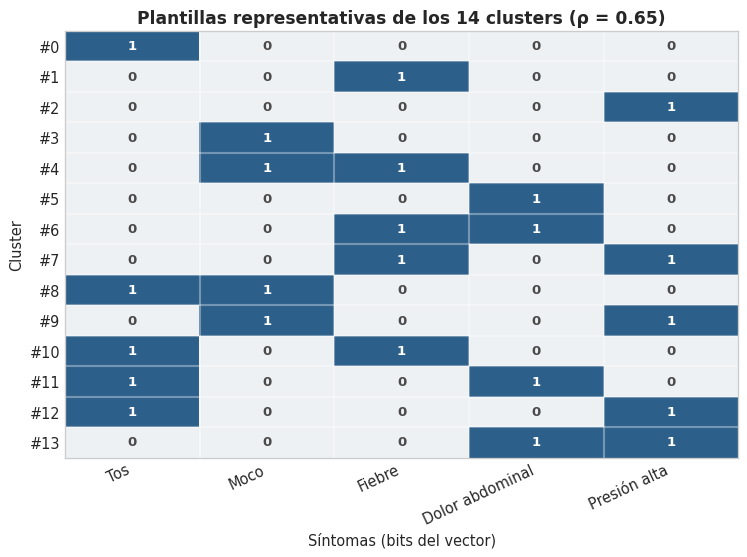

In [24]:
# 1) Heatmap de las plantillas representativas (clusters del entrenamiento).
matriz = [plantillas_train[j] for j in sorted(plantillas_train)]
etiquetas_y = [f"#{j}" for j in sorted(plantillas_train)]

fig, ax = plt.subplots(figsize=(8, 6))
cmap = mpl.colors.ListedColormap(["#eef1f4", PALETA["azul"]])
ax.imshow(matriz, cmap=cmap, aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(nombres_features)))
ax.set_xticklabels(nombres_features, rotation=25, ha="right")
ax.set_yticks(range(len(matriz)))
ax.set_yticklabels(etiquetas_y)
ax.set_xlabel("Síntomas (bits del vector)")
ax.set_ylabel("Cluster")
ax.set_title(f"Plantillas representativas de los {len(matriz)} clusters (ρ = 0.65)")

# Rejilla fina entre celdas y valor del bit en cada una.
ax.set_xticks([x - 0.5 for x in range(1, len(nombres_features))], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, len(matriz))], minor=True)
ax.grid(which="minor", color="white", linewidth=1.6)
ax.grid(which="major", visible=False)
for i, fila in enumerate(matriz):
    for k, bit in enumerate(fila):
        ax.text(k, i, str(bit), ha="center", va="center",
                color="white" if bit == 1 else "#4a4a4a", fontsize=10, fontweight="bold")

fig.tight_layout()
plt.show()

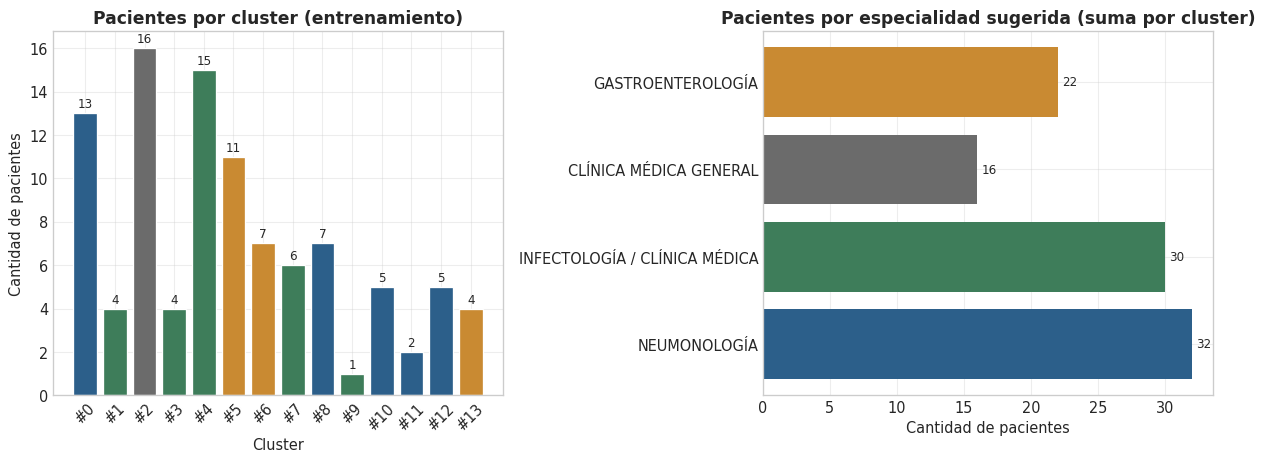

In [25]:
# 2) Distribución de pacientes por cluster y por especialidad sugerida.
clusters_ordenados = sorted(plantillas_train)
cantidades = [conteo_cluster[j] for j in clusters_ordenados]
especialidades = []
for j in clusters_ordenados:
    activos = [nombres_features[i] for i, bit in enumerate(plantillas_train[j]) if bit == 1]
    espec, _ = cg.infer_specialty_and_recommendations(activos)
    especialidades.append(espec)

colores_por_especialidad = {
    "NEUMONOLOGÍA": PALETA["azul"],
    "INFECTOLOGÍA / CLÍNICA MÉDICA": PALETA["verde"],
    "GASTROENTEROLOGÍA": PALETA["ocre"],
    "CARDIOLOGÍA": PALETA["rojo"],
    "CLÍNICA MÉDICA GENERAL": PALETA["gris"],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores = [colores_por_especialidad.get(e, PALETA["violeta"]) for e in especialidades]
barras = axes[0].bar([f"#{j}" for j in clusters_ordenados], cantidades, color=colores, edgecolor="white")
axes[0].bar_label(barras, fontsize=9, padding=2)
axes[0].set_title("Pacientes por cluster (entrenamiento)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Cantidad de pacientes")
axes[0].tick_params(axis="x", rotation=45)

conteo_especialidad = Counter()
for j, espec in zip(clusters_ordenados, especialidades):
    conteo_especialidad[espec] += conteo_cluster[j]   # se suman los pacientes de cada cluster
nombres_esp = list(conteo_especialidad.keys())
barras2 = axes[1].barh(nombres_esp,
                       [conteo_especialidad[e] for e in nombres_esp],
                       color=[colores_por_especialidad.get(e, PALETA["violeta"]) for e in nombres_esp])
axes[1].bar_label(barras2, fontsize=9, padding=3)
axes[1].set_title("Pacientes por especialidad sugerida (suma por cluster)")
axes[1].set_xlabel("Cantidad de pacientes")

fig.tight_layout()
plt.show()

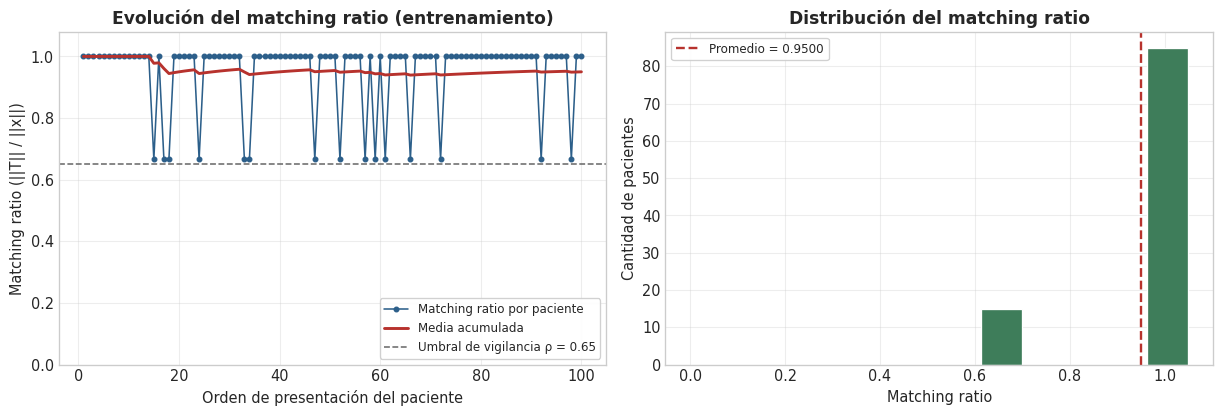

In [26]:
# 3) Evolución del matching ratio a lo largo del entrenamiento.
ratios = res_train["ratios"]
# Media acumulada: promedio de los matching ratios desde el paciente 1 hasta el i-ésimo.
media_acumulada = []
suma = 0.0
for i, r in enumerate(ratios, start=1):
    suma += r
    media_acumulada.append(suma / i)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(1, len(ratios) + 1), ratios, color=PALETA["azul"],
             marker="o", markersize=3.5, linewidth=1.2, label="Matching ratio por paciente")
axes[0].plot(range(1, len(ratios) + 1), media_acumulada, color=PALETA["rojo"],
             linewidth=2.2, label="Media acumulada")
axes[0].axhline(y=0.65, color=PALETA["gris"], linestyle="--", linewidth=1.2,
                label="Umbral de vigilancia ρ = 0.65")
axes[0].set_title("Evolución del matching ratio (entrenamiento)")
axes[0].set_xlabel("Orden de presentación del paciente")
axes[0].set_ylabel("Matching ratio (||T|| / ||x||)")
axes[0].set_ylim(0, 1.08)
axes[0].legend(loc="lower right", fontsize=9)

axes[1].hist(ratios, bins=12, color=PALETA["verde"], edgecolor="white", range=(0, 1.05))
axes[1].axvline(x=metricas_train["avg_matching_ratio"], color=PALETA["rojo"],
                linestyle="--", linewidth=1.8,
                label=f"Promedio = {metricas_train['avg_matching_ratio']:.4f}")
axes[1].set_title("Distribución del matching ratio")
axes[1].set_xlabel("Matching ratio")
axes[1].set_ylabel("Cantidad de pacientes")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

### 8.1 Barrido del umbral de vigilancia ρ

Se entrena la red con cuatro valores de ρ (0.4, 0.5, 0.65 y 0.8) sobre los dos
datasets y se observa cómo cambian la **cantidad de clusters** y la **pureza**.
La expectativa teórica se cumple: a mayor ρ, más clusters (más exigencia, más
fragmentación) y pureza más alta; a menor ρ, menos clusters y grupos más mezclados.

In [27]:
# Barrido de rho: cantidad de clusters y pureza en entrenamiento y validación.
BARRIDO_RHO = [0.4, 0.5, 0.65, 0.8]
filas_barrido = []
for rho_val in BARRIDO_RHO:
    # Entrenamiento
    res_b = art1_entrenar_dataset(patrones, N, M_MAX, rho=rho_val)
    pl_b = art1_plantillas(res_b["t"], res_b["comprometidas"])
    met_b = art1_metricas(res_b["asignaciones"], res_b["ratios"], pl_b)
    # Validación (mismo procedimiento, dataset con etiquetas esperadas)
    res_v = art1_entrenar_dataset(patrones_val, N, M_MAX, rho=rho_val)
    pl_v = art1_plantillas(res_v["t"], res_v["comprometidas"])
    met_v = art1_metricas(res_v["asignaciones"], res_v["ratios"], pl_v)
    pureza = art1_pureza(res_v["asignaciones"], etiquetas_val)
    filas_barrido.append({
        "rho": rho_val,
        "clusters_train": int(met_b["num_clusters"]),
        "mr_train": met_b["avg_matching_ratio"],
        "estab_train": met_b["avg_template_active_bits"],
        "clusters_val": int(met_v["num_clusters"]),
        "mr_val": met_v["avg_matching_ratio"],
        "pureza_val": pureza,
    })

print("BARRIDO DEL UMBRAL DE VIGILANCIA (rho)")
print(f"{'rho':>5} | {'Clusters train':>14} | {'MR train':>9} | {'Estab.':>7} | {'Clusters val':>12} | {'MR val':>8} | {'Pureza val':>10}")
print("-" * 88)
for f in filas_barrido:
    print(f"{f['rho']:>5.2f} | {f['clusters_train']:>14} | {f['mr_train']:>9.4f} | {f['estab_train']:>7.2f} | "
          f"{f['clusters_val']:>12} | {f['mr_val']:>8.4f} | {f['pureza_val'] * 100:>9.2f}%")

BARRIDO DEL UMBRAL DE VIGILANCIA (rho)
  rho | Clusters train |  MR train |  Estab. | Clusters val |   MR val | Pureza val
----------------------------------------------------------------------------------------
 0.40 |              8 |    0.8008 |    1.62 |            7 |   0.8150 |     57.00%
 0.50 |              8 |    0.8008 |    1.62 |            7 |   0.8150 |     57.00%
 0.65 |             14 |    0.9500 |    1.64 |           12 |   0.9600 |     69.00%
 0.80 |             17 |    1.0000 |    1.88 |           17 |   1.0000 |     72.00%


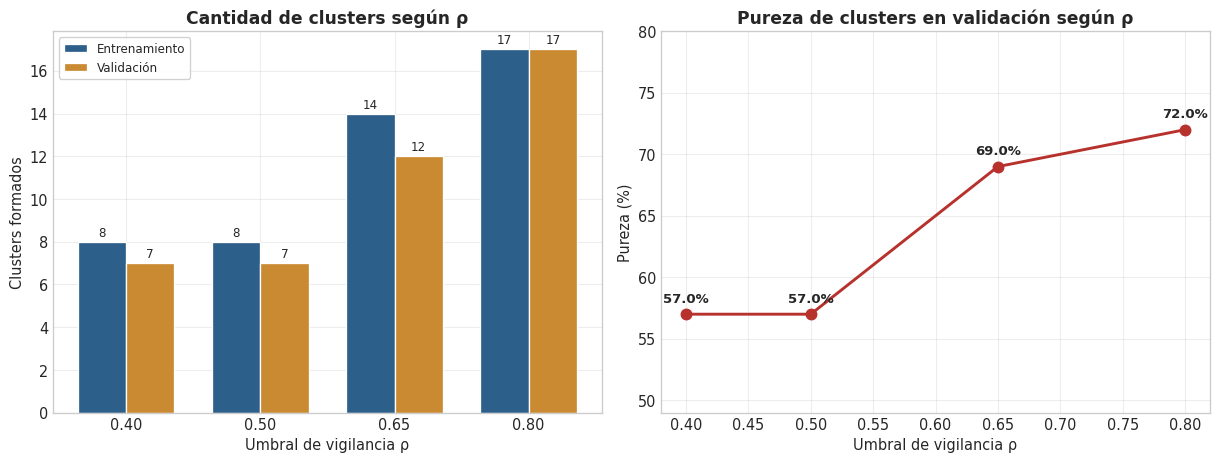

In [28]:
# Gráfico del barrido de rho.
rhos = [f["rho"] for f in filas_barrido]
clusters_tr = [f["clusters_train"] for f in filas_barrido]
clusters_va = [f["clusters_val"] for f in filas_barrido]
purezas = [f["pureza_val"] * 100 for f in filas_barrido]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ancho = 0.36
eje_x = range(len(rhos))
b1 = axes[0].bar([x - ancho / 2 for x in eje_x], clusters_tr, width=ancho,
                 color=PALETA["azul"], label="Entrenamiento", edgecolor="white")
b2 = axes[0].bar([x + ancho / 2 for x in eje_x], clusters_va, width=ancho,
                 color=PALETA["ocre"], label="Validación", edgecolor="white")
axes[0].bar_label(b1, fontsize=9, padding=2)
axes[0].bar_label(b2, fontsize=9, padding=2)
axes[0].set_xticks(list(eje_x))
axes[0].set_xticklabels([f"{r:.2f}" for r in rhos])
axes[0].set_title("Cantidad de clusters según ρ")
axes[0].set_xlabel("Umbral de vigilancia ρ")
axes[0].set_ylabel("Clusters formados")
axes[0].legend(fontsize=9)

axes[1].plot(rhos, purezas, color=PALETA["rojo"], marker="o", markersize=8, linewidth=2.2)
for x, y in zip(rhos, purezas):
    axes[1].annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("Pureza de clusters en validación según ρ")
axes[1].set_xlabel("Umbral de vigilancia ρ")
axes[1].set_ylabel("Pureza (%)")
axes[1].set_ylim(min(purezas) - 8, max(purezas) + 8)

fig.tight_layout()
plt.show()

## 9. Validación externa

El dataset de validación trae una columna **Especialidad esperada** con la
etiqueta de referencia (Neumología, Infectología, Gastroenterología, Cardiología
o Medicina general). ART1 **no ve esa columna**: la red entrena igual que antes,
sin supervisión, y recién después se compara cada cluster con las etiquetas para
calcular la **pureza**.

La pureza responde: *de los pacientes que cayeron en un mismo cluster, ¿qué
fracción comparte la etiqueta esperada?* Se toma la etiqueta mayoritaria de cada
cluster como su "respuesta" y se promedia ponderadamente.

Con $\rho = 0{,}65$ el dataset de validación produce **12 clusters**,
**matching ratio 0.9600**, **estabilidad 1.58** y **pureza 69.00%**.

In [29]:
# Entrenamiento sobre el dataset de validación y métricas con etiquetas de referencia.
res_val = art1_entrenar_dataset(patrones_val, N, M_MAX, rho=0.65)
plantillas_val = art1_plantillas(res_val["t"], res_val["comprometidas"])
metricas_val = art1_metricas(res_val["asignaciones"], res_val["ratios"], plantillas_val)
pureza_val = art1_pureza(res_val["asignaciones"], etiquetas_val)

print("== VALIDACIÓN EXTERNA - rho = 0.65 ==")
print("Registros procesados            :", len(patrones_val))
print("Clusters formados (M)           :", int(metricas_val["num_clusters"]))
print(f"Matching ratio promedio         : {metricas_val['avg_matching_ratio']:.4f}")
print(f"Estabilidad (bits 1 / plantilla): {metricas_val['avg_template_active_bits']:.2f}")
print(f"Pureza de clusters (validación) : {pureza_val * 100:.2f}%")

== VALIDACIÓN EXTERNA - rho = 0.65 ==
Registros procesados            : 100
Clusters formados (M)           : 12
Matching ratio promedio         : 0.9600
Estabilidad (bits 1 / plantilla): 1.58
Pureza de clusters (validación) : 69.00%


In [30]:
# Matriz de contingencia cluster x etiqueta esperada (qué se confunde con qué).
tabla = defaultdict(Counter)
for j, lab in zip(res_val["asignaciones"], etiquetas_val):
    tabla[j][lab] += 1

etiquetas_ordenadas = sorted(set(etiquetas_val))
print("MATRIZ DE CONTINGENCIA: cluster (filas) vs especialidad esperada (columnas)")
print(f"{'Cluster':>8} | {'Plantilla':<14} | " + " | ".join(f"{e[:12]:>12}" for e in etiquetas_ordenadas) + f" | {'Total':>5} | {'Pureza':>7}")
print("-" * 122)
for j in sorted(tabla):
    fila = tabla[j]
    total = sum(fila.values())
    mayor = max(fila.values())
    activos = [nombres_val[i] for i, bit in enumerate(plantillas_val[j]) if bit == 1]
    texto_plant = "+".join(a.split()[0] for a in activos) if activos else "sin sínt."
    print(f"{j:>8} | {texto_plant:<14} | " +
          " | ".join(f"{fila.get(e, 0):>12}" for e in etiquetas_ordenadas) +
          f" | {total:>5} | {mayor / total * 100:>6.1f}%")

print()
print("Etiqueta mayoritaria de cada cluster (la 'respuesta' que daría el sistema):")
for j in sorted(tabla):
    ganadora, n = tabla[j].most_common(1)[0]
    print(f"   Cluster #{j:2d} -> {ganadora} ({n} de {sum(tabla[j].values())} pacientes)")

MATRIZ DE CONTINGENCIA: cluster (filas) vs especialidad esperada (columnas)
 Cluster | Plantilla      |  Cardiología | Gastroentero | Infectología | Medicina gen |   Neumología | Total |  Pureza
--------------------------------------------------------------------------------------------------------------------------
       0 | Tos            |            1 |            1 |            2 |            8 |            2 |    14 |   57.1%
       1 | Moco           |            0 |            0 |            0 |            0 |           12 |    12 |  100.0%
       2 | Presión        |           12 |            0 |            0 |            2 |            0 |    14 |   85.7%
       3 | Fiebre         |            0 |            2 |            7 |            1 |            0 |    10 |   70.0%
       4 | Moco+Fiebre    |            0 |            0 |            3 |            1 |            3 |     7 |   42.9%
       5 | Tos+Fiebre     |            1 |            0 |            6 |            2 |

**Lectura de la matriz (para la defensa).** Hay clusters notablemente puros: el
cluster 1 concentra 12 de 12 pacientes con la misma etiqueta esperada, el
cluster 2 alcanza 12 de 14 y el cluster 6, 12 de 15. Las confusiones se
concentran en tres lugares previsibles:

* los pacientes **sin síntomas** (vector nulo), que la red asigna por convención
  al cluster 0 y que traen etiquetas variadas, sobre todo *Medicina general*;
* las combinaciones que cruzan dominios (por ejemplo tos con fiebre, clusters 4
  y 5), que quedan en un limbo entre *Infectología* y *Neumología* según cuál de
  los dos dominios dominó la plantilla;
* y la etiqueta *Medicina general*, **transversal por definición**: no describe
  un síntoma sino un nivel de atención, así que se reparte entre muchos clusters
  y penaliza la pureza aunque el agrupamiento sintomático sea razonable.

Por eso 69% es un número esperable para este diseño y no un fallo de la red.

## 10. Discusión y limitaciones

### 10.1 Estabilidad-plasticidad en este dataset

ART1 garantiza que un cluster no se destruye al llegar un patrón nuevo: solo se
afina por intersección. En nuestros datos esto se ve en que las plantillas
terminan siendo combinaciones **exactas** de síntomas, nunca mezclas inventadas.
El costo de esa estabilidad es que una plantilla **solo puede perder bits**: si
un paciente con un síntoma extra entra temprano al cluster, ese síntoma se
pierde de la plantilla para siempre y el cluster queda más estrecho de lo que
debería. Es el trade-off clásico: estabilidad a costa de cierta rigidez.

### 10.2 Sensibilidad al umbral de vigilancia ρ

El barrido de la sección 8.1 muestra el efecto esperado: con ρ = 0.4 y 0.5 se
forman 8 clusters de entrenamiento con pureza 57%; con ρ = 0.65, 14 clusters y
69%; con ρ = 0.8, 17 clusters y 72%. Más ρ implica más pureza pero clusters de
2 o 3 pacientes, que en la práctica clínica son "categorías" demasiado chicas
para ser útiles. Que ρ = 0.4 y ρ = 0.5 den idéntico resultado se explica por la
**discretización del matching ratio**: con 5 bits los valores posibles son
fracciones de quintos, y ningún caso cae en el intervalo [0.4, 0.5) durante esta
corrida. La elección de ρ = 0.65 como valor por defecto es un compromiso, no un
óptimo demostrado.

### 10.3 Orden de presentación de los patrones

ART1 es **incremental y sensible al orden**: la primera vez que aparece una
combinación de síntomas decide qué plantilla se forma, y los pacientes
siguientes se cuelgan de ahí. Con el flag `--shuffle` del CLI puede medirse esa
sensibilidad barajando el dataset varias veces: la cantidad de clusters varía
entre corridas aunque el orden de magnitud se mantiene. En la defensa conviene
tenerlo presente como propiedad del algoritmo, no como defecto de la
implementación. La medición concreta de esa sensibilidad, con cinco corridas
barajadas y semilla fija, se presenta en la sección 10.7.

### 10.4 Ruido y datos faltantes

ART1 asume entradas binarias limpias. Un síntoma mal tildado (0 por 1) cambia
la norma del patrón y puede mover al paciente de cluster; un síntoma fantasma
accedido con `1` puede crear un cluster espurio. El saneo de celdas de la
sección 3 cubre el formato, no la calidad clínica del dato: eso sigue siendo
responsabilidad de quien carga la planilla.

### 10.5 Sesgos del dataset sintético

Los datos del TFI son **sintéticos y balanceados por diseño** (20 pacientes por
especialidad esperada), con 5 síntomas y combinaciones relativamente limpias.
En datos reales: los síntomas son correlacionados, hay comorbilidades, clases
muy desbalanceadas y mucha más dimensionalidad. La pureza de 69% **no es
extrapolable** a un entorno clínico real sin reentrenar y revalidar.

### 10.6 Aspectos éticos del diagnóstico asistido

* **La red no diagnostica**: agrupa patrones y sugiere una derivación. La
  decisión es y sigue siendo del profesional de salud.
* **Trazabilidad**: toda la cadena (bits → cluster → plantilla → especialidad)
  es auditable, que es una ventaja real frente a modelos opacos.
* **Daño asimétrico**: en medicina, un falso negativo (no derivar a tiempo)
  pesa mucho más que un falso positivo. El umbral ρ debe elegirse con el equipo
  clínico, no por criterio numérico.
* **Datos y consentimiento**: con datos reales hacen falta consentimiento
  informado, anonimización y evaluación de sesgos por grupo poblacional antes
  de cualquier uso que no sea académico.

### 10.7 Orden de presentación: test de estabilidad ante barajado

La sensibilidad al orden enunciada en 10.3 se midió de forma directa: se barajó
el orden de presentación de los patrones **5 corridas con semilla fija (42)** y
se reentrenó la red desde cero en cada una, con $\rho = 0{,}65$. Los números
que siguen los produce el propio `src/CarGross.py` mediante
`--shuffle 5 --seed 42`, no están cargados a mano.

**Lo que se observa, sin maquillar:**

* **El número de clusters SÍ depende del orden de presentación.** En
  entrenamiento las corridas barajadas dieron entre **13 y 15** clusters
  (alrededor de los 14 del orden original) y en validación entre **12 y 14**
  (alrededor de los 12). Es la sensibilidad al orden clásica de ART1: los
  patrones que llegan primero reclaman categorías y condicionan a los que
  vienen después; un paciente que llega "temprano" puede abrir una categoría
  que, con otro orden, no haría falta.
* **El matching ratio, en cambio, es notablemente estable.** En entrenamiento se
  mantuvo entre **0.9500 y 0.9600** y en validación entre **0.9600 y 0.9633**.
  O sea: con el orden cambia la **granularidad** de la partición (más o menos
  categorías), no la **calidad** del agrupamiento (la proporción del patrón que
  explica su plantilla apenas se mueve).
* **Es la otra cara del dilema estabilidad-plasticidad.** Con ρ alto la red es
  más exigente: crea más categorías y, como cada una cubre menos casos, el orden
  pesa más. Con ρ bajo las categorías son más gruesas y la partición aguanta
  mejor el reordenamiento: en el barrido de la sección 8.1, ρ = 0.4 y ρ = 0.5
  daban **8 clusters** con pureza 57%, es decir menos categorías y más
  robustas al orden, a costa de mezclar especialidades.
* **Es una limitación a declarar, no un defecto escondido.** ART1 no converge a
  una partición única como un k-means con inicialización determinista: la
  partición depende del recorrido. Lo que se mantiene estable acá es la calidad
  del agrupamiento y la lectura clínica de las plantillas, y eso es lo que hay
  que defender.


In [31]:
# Test de estabilidad ante el barajado del orden de presentación.
# Se ejecuta el CLI real (src/CarGross.py) con --shuffle 5 --seed 42 sobre cada
# dataset y se parsea su stdout: los números de la tabla NO están hardcodeados.
PATRON_CORRIDA = re.compile(
    r"Corrida Barajada #(\d+):\s*(\d+) clusters formados \| Matching Ratio: ([0-9.]+)")
PATRON_PROMEDIO = re.compile(
    r"Promedio post-barajado: ([0-9.]+) clusters \(Base original: (\d+)\) \| Matching Ratio: ([0-9.]+)")

def ejecutar_barajado(dataset: Path, etiqueta: str) -> str:
    """Corre src/CarGross.py --shuffle 5 --seed 42 y devuelve su stdout."""
    carpeta_salida = Path(tempfile.gettempdir()) / "art1_shuffle_demo"
    carpeta_salida.mkdir(parents=True, exist_ok=True)
    comando = [sys.executable, str(RAIZ / "src" / "CarGross.py"), str(dataset),
               "--rho", "0.65", "--shuffle", "5", "--seed", "42",
               "--output", str(carpeta_salida / f"{etiqueta}.csv")]
    entorno = dict(os.environ, PYTHONIOENCODING="utf-8")
    proc = subprocess.run(comando, capture_output=True, encoding="utf-8",
                          errors="replace", env=entorno, cwd=str(RAIZ))
    assert proc.returncode == 0, f"El CLI falló: {proc.stderr[-500:]}"
    return proc.stdout

def parsear_barajado(texto: str) -> dict:
    corridas = {}
    for m in PATRON_CORRIDA.finditer(texto):
        corridas[int(m.group(1))] = (int(m.group(2)), float(m.group(3)))
    base_clusters, base_mr = None, None
    for linea in texto.splitlines():
        if "Categorías / Clusters Formados" in linea:
            base_clusters = int(linea.rsplit(":", 1)[-1].strip())
        elif "Matching Ratio Promedio" in linea:
            base_mr = float(linea.rsplit(":", 1)[-1].strip())
    m = PATRON_PROMEDIO.search(texto)
    return {
        "base_clusters": base_clusters,
        "base_mr": base_mr,
        "corridas": [corridas[k] for k in sorted(corridas)],
        "prom_clusters": float(m.group(1)) if m else None,
        "prom_mr": float(m.group(3)) if m else None,
    }

# Valores de referencia de las corridas --seed 42. Se usan SOLO si la ejecución
# del CLI fallara por el entorno, para que la celda no rompa el notebook en una
# demo en vivo; en condiciones normales la tabla sale del CLI.
REFERENCIA = {
    "entrenamiento": {
        "base_clusters": 14, "base_mr": 0.9500,
        "corridas": [(14, 0.9600), (14, 0.9500), (15, 0.9567), (15, 0.9600), (13, 0.9600)],
        "prom_clusters": 14.20, "prom_mr": 0.9573,
    },
    "validacion": {
        "base_clusters": 12, "base_mr": 0.9600,
        "corridas": [(12, 0.9600), (14, 0.9600), (13, 0.9633), (13, 0.9600), (13, 0.9600)],
        "prom_clusters": 13.00, "prom_mr": 0.9607,
    },
}

barajado = {}
for etiqueta, ruta in (("entrenamiento", RUTA_TRAIN), ("validacion", RUTA_VAL)):
    try:
        barajado[etiqueta] = parsear_barajado(ejecutar_barajado(ruta, etiqueta))
        barajado[etiqueta]["fuente"] = "src/CarGross.py --shuffle 5 --seed 42 (stdout real)"
    except Exception as exc:
        print("Aviso: no se pudo ejecutar el CLI:", exc)
        barajado[etiqueta] = dict(REFERENCIA[etiqueta])
        barajado[etiqueta]["fuente"] = "corridas --seed 42 (valores de referencia)"

print("TEST DE ESTABILIDAD ANTE EL BARAJADO DEL ORDEN DE PRESENTACIÓN")
print("Comando: python src/CarGross.py <dataset> --rho 0.65 --shuffle 5 --seed 42")
print()
for etiqueta in ("entrenamiento", "validacion"):
    d = barajado[etiqueta]
    print(f"DATASET DE {etiqueta.upper()} - base sin barajar: {d['base_clusters']} clusters | "
          f"Matching Ratio {d['base_mr']:.4f}")
    print(f"{'Corrida':>8} | {'Clusters':>8} | {'Matching Ratio':>14}")
    print("-" * 38)
    for i, (cl, mr) in enumerate(d["corridas"], start=1):
        print(f"{i:>8} | {cl:>8} | {mr:>14.4f}")
    print(f"{'Promedio':>8} | {d['prom_clusters']:>8.2f} | {d['prom_mr']:>14.4f}")
    cls = [c for c, _ in d["corridas"]]
    mrs = [m for _, m in d["corridas"]]
    print(f"Rango observado: clusters {min(cls)}-{max(cls)} | MR {min(mrs):.4f}-{max(mrs):.4f}")
    print(f"Fuente: {d['fuente']}")
    print()


TEST DE ESTABILIDAD ANTE EL BARAJADO DEL ORDEN DE PRESENTACIÓN
Comando: python src/CarGross.py <dataset> --rho 0.65 --shuffle 5 --seed 42

DATASET DE ENTRENAMIENTO - base sin barajar: 14 clusters | Matching Ratio 0.9500
 Corrida | Clusters | Matching Ratio
--------------------------------------
       1 |       14 |         0.9600
       2 |       14 |         0.9500
       3 |       15 |         0.9567
       4 |       15 |         0.9600
       5 |       13 |         0.9600
Promedio |    14.20 |         0.9573
Rango observado: clusters 13-15 | MR 0.9500-0.9600
Fuente: src/CarGross.py --shuffle 5 --seed 42 (stdout real)

DATASET DE VALIDACION - base sin barajar: 12 clusters | Matching Ratio 0.9600
 Corrida | Clusters | Matching Ratio
--------------------------------------
       1 |       12 |         0.9600
       2 |       14 |         0.9600
       3 |       13 |         0.9633
       4 |       13 |         0.9600
       5 |       13 |         0.9600
Promedio |    13.00 |         0

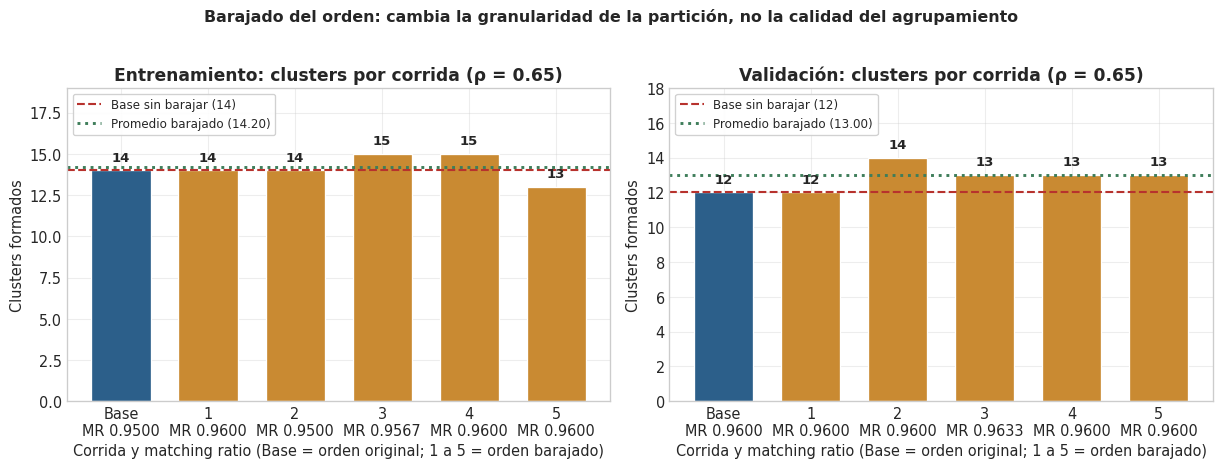

In [32]:
# Gráfico: nº de clusters por corrida barajada vs la base, en train y validación.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, clave, titulo in zip(axes, ("entrenamiento", "validacion"), ("Entrenamiento", "Validación")):
    d = barajado[clave]
    clusters = [d["base_clusters"]] + [c for c, _ in d["corridas"]]
    ratios = [d["base_mr"]] + [m for _, m in d["corridas"]]
    etiquetas_x = [f"Base\nMR {ratios[0]:.4f}"] + [f"{i}\nMR {m:.4f}"
                 for i, (_, m) in enumerate(d["corridas"], start=1)]
    colores = [PALETA["azul"]] + [PALETA["ocre"]] * len(d["corridas"])

    barras = ax.bar(etiquetas_x, clusters, color=colores, edgecolor="white", width=0.68)
    ax.bar_label(barras, fontsize=10, fontweight="bold", padding=5)
    ax.axhline(d["base_clusters"], color=PALETA["rojo"], linestyle="--", linewidth=1.6,
               label=f"Base sin barajar ({d['base_clusters']})")
    ax.axhline(d["prom_clusters"], color=PALETA["verde"], linestyle=":", linewidth=2.2,
               label=f"Promedio barajado ({d['prom_clusters']:.2f})")
    ax.set_title(f"{titulo}: clusters por corrida (ρ = 0.65)")
    ax.set_xlabel("Corrida y matching ratio (Base = orden original; 1 a 5 = orden barajado)")
    ax.set_ylabel("Clusters formados")
    ax.set_ylim(0, max(clusters) + 4)
    ax.legend(fontsize=9, loc="upper left")

fig.suptitle("Barajado del orden: cambia la granularidad de la partición, no la calidad del agrupamiento",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


### 10.8 Preguntas probables del jurado y respuestas cortas

**"¿Es estable tu red?"**
Sí en lo que importa y no en lo accesorio. La calidad del agrupamiento es
estable: el matching ratio se mantuvo entre 0.9500 y 0.9600 en entrenamiento y
entre 0.9600 y 0.9633 en validación a lo largo de cinco corridas barajadas. Lo
que varía es la granularidad: entre 13 y 15 clusters en entrenamiento y entre
12 y 14 en validación. Respuesta corta: "la partición no es única, pero el
criterio de calidad del agrupamiento sí es robusto".

**"¿Por qué cambia el número de clusters?"**
Porque ART1 es incremental y sensible al orden de presentación: los patrones
que llegan primero reclaman categorías y condicionan a los que vienen después.
Si un paciente llega temprano, su combinación de síntomas puede abrir una
categoría que con otro orden no haría falta. Es una propiedad del algoritmo,
conocida desde el trabajo original de Carpenter y Grossberg, no un error de la
implementación.

**"¿Qué pasa si los datos llegan en otro orden?"**
Se reentrena y se obtiene una partición con un número de clusters parecido, del
mismo orden de magnitud, y con prácticamente la misma calidad, porque el
matching ratio apenas se mueve. Por eso el sistema reporta la plantilla de cada
cluster y su especialidad sugerida: la lectura clínica es auditable corrida a
corrida aunque los límites entre categorías cambien un poco. Si se exigiera una
partición única y exactamente reproducible, habría que fijar el orden de
presentación o migrar a un algoritmo con inicialización determinista, y eso ya
es otro modelo con otras propiedades.


## 11. Cómo reproducir el CLI

Todo lo que muestra este notebook se puede reproducir desde la línea de
comandos con el módulo de producción. Desde la **raíz del repo**:

```powershell
# Autotest de verificación
python src/CarGross.py --test

# Entrenamiento completo (rho por defecto: 0.65)
python src/CarGross.py data/dataset_entrenamiento_ART1.xlsx --rho 0.65 --output results/res_entrenamiento.csv --save-txt results/res_entrenamiento.txt

# Validación externa (calcula la pureza contra la columna de especialidad)
python src/CarGross.py data/dataset_validacion_ART1.xlsx --rho 0.65 --output results/res_validacion.csv --save-txt results/res_validacion.txt

# Barrido de rho (cambiar 0.8 por 0.4, 0.5 o 0.65)
python src/CarGross.py data/dataset_entrenamiento_ART1.xlsx --rho 0.8 --output results/res_train_rho08.csv

# Manual de referencia técnica
python src/CarGross.py --man
```

La celda siguiente **ejecuta esos comandos de verdad** (en un proceso aparte,
con salidas a una carpeta temporal) y compara los números que imprime el CLI
con los que calculó este notebook. Es la última verificación antes de cerrar:
notebook y sistema de producción no pueden divergir.

In [33]:
# Ejecución real del CLI y comparación automática contra lo calculado en el notebook.
def correr_cli(dataset: Path, rho: float, etiqueta: str):
    carpeta_salida = Path(tempfile.gettempdir()) / "art1_cli_demo"
    carpeta_salida.mkdir(parents=True, exist_ok=True)
    salida_csv = carpeta_salida / f"{etiqueta}_rho{rho}.csv"
    comando = [sys.executable, str(RAIZ / "src" / "CarGross.py"), str(dataset),
               "--rho", str(rho), "--output", str(salida_csv)]
    entorno = dict(os.environ, PYTHONIOENCODING="utf-8")
    proc = subprocess.run(comando, capture_output=True, encoding="utf-8",
                          errors="replace", env=entorno, cwd=str(RAIZ))
    assert proc.returncode == 0, f"El CLI falló: {proc.stderr[-500:]}"
    return proc.stdout

def extraer_metricas(texto: str) -> dict:
    extraidas = {}
    for linea in texto.splitlines():
        for clave, patron in (("clusters", r"Categorías / Clusters Formados \(M\):"),
                              ("matching_ratio", r"Matching Ratio Promedio"),
                              ("estabilidad", r"Estabilidad \(bits"),
                              ("pureza", r"Pureza de Clusters")):
            if re.search(patron, linea, re.IGNORECASE):
                valor = linea.rsplit(":", 1)[-1].strip().replace("%", "")
                extraidas[clave] = float(valor)
    return extraidas

salida_train_cli = correr_cli(RUTA_TRAIN, 0.65, "entrenamiento")
salida_val_cli = correr_cli(RUTA_VAL, 0.65, "validacion")
cli_train = extraer_metricas(salida_train_cli)
cli_val = extraer_metricas(salida_val_cli)

print("Métricas reportadas por el CLI (stdout real de src/CarGross.py):")
print("   entrenamiento:", cli_train)
print("   validación   :", cli_val)
print()
comparaciones = [
    ("clusters train", cli_train["clusters"], metricas_train["num_clusters"]),
    ("matching ratio train", cli_train["matching_ratio"], metricas_train["avg_matching_ratio"]),
    ("estabilidad train", cli_train["estabilidad"], round(metricas_train["avg_template_active_bits"], 2)),
    ("clusters val", cli_val["clusters"], metricas_val["num_clusters"]),
    ("matching ratio val", cli_val["matching_ratio"], metricas_val["avg_matching_ratio"]),
    ("estabilidad val", cli_val["estabilidad"], round(metricas_val["avg_template_active_bits"], 2)),
    ("pureza val", cli_val["pureza"], round(pureza_val * 100, 2)),
]
print(f"{'Métrica':<24} | {'CLI':>10} | {'Notebook':>10} | {'¿Coincide?':>10}")
print("-" * 64)
todo_ok = True
for nombre, valor_cli, valor_nb in comparaciones:
    ok = abs(float(valor_cli) - float(valor_nb)) < 0.011
    todo_ok = todo_ok and ok
    print(f"{nombre:<24} | {float(valor_cli):>10.4f} | {float(valor_nb):>10.4f} | {'SÍ' if ok else 'NO':>10}")

print()
print("VERIFICACIÓN FINAL CLI vs NOTEBOOK:", "COINCIDENCIA TOTAL" if todo_ok else "DIVERGENCIA DETECTADA")
assert todo_ok

Métricas reportadas por el CLI (stdout real de src/CarGross.py):
   entrenamiento: {'clusters': 14.0, 'matching_ratio': 0.95, 'estabilidad': 1.64}
   validación   : {'clusters': 12.0, 'matching_ratio': 0.96, 'estabilidad': 1.58, 'pureza': 69.0}

Métrica                  |        CLI |   Notebook | ¿Coincide?
----------------------------------------------------------------
clusters train           |    14.0000 |    14.0000 |         SÍ
matching ratio train     |     0.9500 |     0.9500 |         SÍ
estabilidad train        |     1.6400 |     1.6400 |         SÍ
clusters val             |    12.0000 |    12.0000 |         SÍ
matching ratio val       |     0.9600 |     0.9600 |         SÍ
estabilidad val          |     1.5800 |     1.5800 |         SÍ
pureza val               |    69.0000 |    69.0000 |         SÍ

VERIFICACIÓN FINAL CLI vs NOTEBOOK: COINCIDENCIA TOTAL


In [34]:
# Fragmento del reporte TXT que genera el CLI, tal cual sale del sistema real.
lineas_resumen = [l for l in salida_val_cli.splitlines()
                  if l.strip() and (l[0].isdigit() or "rho" in l.lower() or "Archivo" in l)]
print("Extracto del stdout del CLI sobre el dataset de validación:")
for l in lineas_resumen:
    print("   ", l)

Extracto del stdout del CLI sobre el dataset de validación:
    -> Archivo de entrada: C:\Users\camil\Proyectos\ia2026\data\dataset_validacion_ART1.xlsx
    -> Parámetro de Vigilancia (rho): 0.65
    1. Categorías / Clusters Formados (M): 12
    2. Matching Ratio Promedio (||T||/||X||): 0.9600
    3. Estabilidad (Bits '1' activos promedio por plantilla): 1.58
    4. Pureza de Clusters (Validación Externa): 69.00%
    [ÉXITO] Resultados guardados en CSV 'C:\Users\camil\AppData\Local\Temp\art1_cli_demo\validacion_rho0.65.csv'.


### Cierre

Con esto queda cerrado el recorrido completo del TFI: teoría ART1, datos reales
saneados, algoritmo implementado fórmula por fórmula, un ejemplo rastreado con
números verificables a mano, entrenamiento y validación sobre los 100 pacientes,
métricas del sistema, visualizaciones para la exposición y verificación
automática de que el notebook y `src/CarGross.py` dicen exactamente lo mismo.

**Recordatorio final para la defensa.** ART1 no diagnostica: agrupa perfiles
sintomáticos y sugiere una derivación. El umbral de vigilancia ρ es una
decisión de diseño que debe consensuarse con el criterio clínico, y todo
resultado de este sistema debe ser validado por un profesional médico.